# Module 3: Player Segmentation (K-Means Clustering)

**Goal:** Segment IPL batsmen into 4 archetypes using K-Means + PCA visualization



## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

engine = create_engine('sqlite:///../ipl.db')
IPL_BLUE = '#1B3D6F'
IPL_ORANGE = '#E8820C'

print('Setup complete.')

Setup complete.


## Step 1 — Building Player Feature Matrix

In [4]:
q = '''
SELECT 
    batter,
    SUM(batsman_runs) AS total_runs,
    ROUND(AVG(batsman_runs), 2) AS avg_runs,
    ROUND(SUM(batsman_runs) * 100.0 / COUNT(*), 2) AS strike_rate,
    SUM(CASE WHEN batsman_runs >= 4 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS boundary_pct,
    SUM(CASE WHEN batsman_runs = 6 THEN 1 ELSE 0 END) AS sixes,
    COUNT(DISTINCT match_id) AS matches_played
FROM deliveries
GROUP BY batter
HAVING SUM(batsman_runs) >= 500
'''
batsmen = pd.read_sql(q, engine)

print(f'Batsmen with 500+ runs: {len(batsmen)}')
batsmen.head()

Batsmen with 500+ runs: 149


,batter,total_runs,avg_runs,strike_rate,boundary_pct,sixes,matches_played
0,A Badoni,634,1.26,125.54,13.861386,24,35
1,A Symonds,974,1.25,124.71,14.724712,41,36
2,AB de Villiers,5181,1.49,148.58,19.128190,253,170
3,AC Gilchrist,2069,1.33,133.05,21.286174,92,80
4,AD Mathews,724,1.21,120.87,12.186978,29,41


## Step 2 — Normalizing & Applying K-Means with Elbow Method

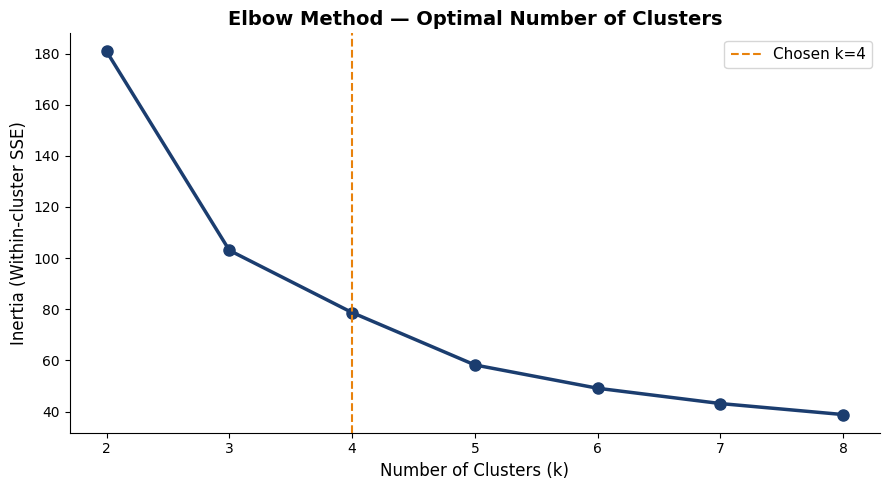

Elbow chart saved.


In [5]:
features = ['avg_runs', 'strike_rate', 'boundary_pct']
X = batsmen[features].dropna()
batsmen = batsmen.loc[X.index]  # Keeping only rows without NaN

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot Elbow
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertia, marker='o', color=IPL_BLUE, linewidth=2.5, markersize=8)
ax.axvline(x=4, color=IPL_ORANGE, linestyle='--', linewidth=1.5, label='Chosen k=4')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/chart_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow chart saved.')

In [6]:
# Apply K-Means with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
batsmen['cluster'] = km.fit_predict(X_scaled)

# View cluster stats
cluster_stats = batsmen.groupby('cluster')[features].mean().round(2)
print('=== CLUSTER MEANS ===')
cluster_stats

=== CLUSTER MEANS ===


,avg_runs,strike_rate,boundary_pct
cluster,,,
0,1.36,135.88,18.59
1,1.24,124.34,15.54
2,1.14,113.50,13.59
3,1.54,153.67,22.24


## Step 3 — Labelling Clusters & Visualize with PCA

In [7]:
# Auto-label clusters based on their stats
cluster_stats = batsmen.groupby('cluster')[features].mean()

cluster_map = {}
# Highest strike rate = Aggressive Finisher
cluster_map[cluster_stats['strike_rate'].idxmax()] = 'Aggressive Finisher'
# Highest avg_runs = Anchor Batsman (after removing Finisher)
remaining = [c for c in cluster_stats.index if c not in cluster_map]
cluster_map[cluster_stats.loc[remaining, 'avg_runs'].idxmax()] = 'Anchor Batsman'
# From remaining: highest boundary_pct = Match Winner
remaining = [c for c in cluster_stats.index if c not in cluster_map]
cluster_map[cluster_stats.loc[remaining, 'boundary_pct'].idxmax()] = 'Match Winner'
# Last one = Supporting Player
last = [c for c in cluster_stats.index if c not in cluster_map][0]
cluster_map[last] = 'Supporting Player'

batsmen['player_type'] = batsmen['cluster'].map(cluster_map)

print('=== CLUSTER LABELS ===')
print(cluster_map)
print('\n=== PLAYER TYPE COUNTS ===')
print(batsmen['player_type'].value_counts())

=== CLUSTER LABELS ===
{3: 'Aggressive Finisher', 0: 'Anchor Batsman', 1: 'Match Winner', 2: 'Supporting Player'}

=== PLAYER TYPE COUNTS ===
player_type
Match Winner           53
Anchor Batsman         49
Supporting Player      28
Aggressive Finisher    19
Name: count, dtype: int64


In [10]:
# PCA 2D Scatter
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

batsmen['pca1'] = coords[:,0]
batsmen['pca2'] = coords[:,1]

explained = pca.explained_variance_ratio_
print(f'PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Total={sum(explained):.1%}')

color_map = {
    'Aggressive Finisher': '#E8820C',
    'Anchor Batsman': '#1B3D6F',
    'Match Winner': '#4CAF50',
    'Supporting Player': '#2E6DA4'
}

fig = px.scatter(
    batsmen,
    x='pca1',
    y='pca2',
    color='player_type',
    hover_data=['batter','strike_rate','avg_runs','total_runs'],
    title='IPL Batsman Segments — K-Means Clustering (PCA Projection)',
    color_discrete_map=color_map,
    labels={
        'pca1': f'PC1 ({explained[0]:.1%} variance)',
        'pca2': f'PC2 ({explained[1]:.1%} variance)',
        'player_type': 'Player Archetype'
    }
)

fig.update_traces(marker=dict(size=7, opacity=0.8))

fig.update_layout(
    title_font_size=16,
    title_x=0.5,
    plot_bgcolor='white',
    legend_title='Player Archetype',
    height=600
)

fig.write_image('../outputs/chart_clustering_pca.png', width=1000, height=650)

fig.show()

print('PCA scatter saved.')

PCA explained variance: PC1=92.9%, PC2=7.1%, Total=100.0%


PCA scatter saved.


In [12]:
# Print top 5 players per archetype
print('=== TOP 5 PLAYERS PER ARCHETYPE (by total runs) ===')

for ptype in batsmen['player_type'].unique():
    
    top5 = (
        batsmen[batsmen['player_type'] == ptype]
        .nlargest(5, 'total_runs')[['batter','total_runs','strike_rate','avg_runs']]
    )

    print(f'\n🏏 {ptype}:')
    print(top5.to_string(index=False))

=== TOP 5 PLAYERS PER ARCHETYPE (by total runs) ===

🏏 Match Winner:
    batter  total_runs  strike_rate  avg_runs
   V Kohli        8014       128.51      1.29
  S Dhawan        6769       123.45      1.23
 RG Sharma        6630       127.92      1.28
  MS Dhoni        5243       132.84      1.33
RV Uthappa        4954       126.15      1.26

🏏 Aggressive Finisher:
        batter  total_runs  strike_rate  avg_runs
AB de Villiers        5181       148.58      1.49
    GJ Maxwell        2772       150.49      1.50
      V Sehwag        2728       148.83      1.49
    AD Russell        2488       164.22      1.64
       PP Shaw        1892       143.22      1.43

🏏 Anchor Batsman:
      batter  total_runs  strike_rate  avg_runs
   DA Warner        6567       135.43      1.35
    SK Raina        5536       132.54      1.33
    CH Gayle        4997       142.12      1.42
  KD Karthik        4843       131.35      1.31
F du Plessis        4571       133.07      1.33

🏏 Supporting Player:
  

In [13]:
# Save cluster results
batsmen.to_csv('../data/processed/player_segments.csv', index=False)

print('\n✅ MODULE 3 COMPLETE!')
print('Elbow chart saved ✓')
print('PCA scatter saved ✓')
print('player_segments.csv created ✓')
print('\nPlayer type distribution:')
print(batsmen['player_type'].value_counts().to_string())


✅ MODULE 3 COMPLETE!
Elbow chart saved ✓
PCA scatter saved ✓
player_segments.csv created ✓

Player type distribution:
player_type
Match Winner           53
Anchor Batsman         49
Supporting Player      28
Aggressive Finisher    19


**Outcome:** Elbow plot saved, PCA scatter saved, `player_segments.csv` created

> 💡 The PCA scatter plot is my **#1 GitHub visual** from this project.